# Chapter 1: Metric Spaces

**Source span.** A Course in Metric Geometry, Chapter 1, printed pages 1-24, PDF pages 16-39. I used the source for section order, terminology, examples, and theorem orientation only; the exposition, code, figures, and checks here are original.

**Chapter question.** What information is carried by distances alone? This notebook treats a metric as data that can be inspected: a distance table, a quotient, a family of balls, a Lipschitz constant, a Cauchy tail, a finite net, or a covering weight.


## Translation Guide

| Book concept | Computational representation | Inspection target |
| --- | --- | --- |
| Metric axioms, including infinite distances | finite distance matrices with `np.inf` | zero diagonal, symmetry, triangle inequality, finite-distance equivalence classes |
| Distance-preserving maps and isometries | before/after pairwise distance matrices | all distances agree; bijectivity decides whether it is an isometry |
| Semi-metric quotient | points in `R^2` with `abs((x+y)-(x'+y'))` | zero-distance fibers collapse to one real coordinate |
| Examples | discrete, log, Euclidean, product, dilation, subspace, circle arc, norm metrics | formulas change size, topology, or geodesic meaning |
| Topology and Lipschitz maps | balls, distance-to-set plots, sampled dilatation | balls generate neighborhoods; slopes bound distortion |
| Completeness and compactness | Cauchy tails, contractions, finite nets, separated sets | Cauchy tails land exactly in complete spaces; compact metric spaces are complete plus totally bounded |
| Hausdorff measure and dimension | Cantor covering weights | below the critical exponent weights grow, above it they shrink |

## Source Coverage Ledger

The chapter is intentionally treated as a compact reference spine, so the notebook keeps a ledger that maps every source section to an inspectable artifact. Definitions are checked with finite and infinite distance matrices, examples are compared by changing the distance formula on the same sampled set, topology and Lipschitz ideas are shown through balls and nonexpanding functions, completeness and compactness are represented by Cauchy tails and finite nets, and Hausdorff dimension is probed through scale-dependent Cantor covers. This ledger is a coverage check, not a source-text extraction.

The reader should come away with two habits. First, every claimed metric property can be tested on a small distance table before it is trusted in an abstract space. Second, topological or measure-theoretic conclusions depend on the chosen distance, not on the underlying set alone. The log metric on a sampled real line, the arc and chord metrics on a circle, and the quotient of a semi-metric all keep this distinction visible. Later chapters reuse these ideas when paths, curvature, convergence, and large-scale equivalence are defined entirely through distance behavior.


In [1]:
from pathlib import Path
import json, math
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from IPython.display import Image, HTML, display

try:
    import plotly.graph_objects as go
except Exception as exc:
    go = None
    PLOTLY_IMPORT_ERROR = repr(exc)
else:
    PLOTLY_IMPORT_ERROR = None

def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "source_map.json").exists() and (candidate / "AGENTS.md").exists():
            return candidate
    raise RuntimeError("Could not find course root")

BOOK_ROOT = find_book_root()
ARTIFACT_DIR = BOOK_ROOT / "artifacts" / "chapter-01"
FIG_DIR = ARTIFACT_DIR / "figures"
HTML_DIR = ARTIFACT_DIR / "html"
CHECK_DIR = ARTIFACT_DIR / "checks"
TABLE_DIR = ARTIFACT_DIR / "tables"
for directory in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

def rel(path):
    return str(Path(path).relative_to(BOOK_ROOT)).replace("\\", "/")

def save_json(data, path):
    Path(path).write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return Path(path)

def save_fig(fig, path):
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    return Path(path)

def display_artifact(path):
    path = Path(path)
    if path.suffix.lower() == ".png":
        display(Image(filename=str(path)))
    elif path.suffix.lower() == ".html":
        display(HTML(f'<a href="{rel(path)}" target="_blank">Open {rel(path)}</a>'))
    else:
        display(HTML(f"<code>{rel(path)}</code>"))

def pairwise(points, dist):
    n = len(points)
    D = np.zeros((n, n), dtype=float)
    for i, p in enumerate(points):
        for j, q in enumerate(points):
            D[i, j] = dist(p, q)
    return D

def metric_report(D, labels=None, tol=1e-9):
    D = np.array(D, dtype=float)
    n = D.shape[0]
    labels = labels or [str(i) for i in range(n)]
    violations = []
    for i in range(n):
        for j in range(n):
            for k in range(n):
                lhs, rhs = D[i, k], D[i, j] + D[j, k]
                if np.isfinite(lhs) and np.isfinite(rhs) and lhs > rhs + tol:
                    violations.append((labels[i], labels[j], labels[k], float(lhs), float(rhs)))
    return {
        "nonnegative_or_infinite": bool(np.all((D >= -tol) | np.isinf(D))),
        "zero_diagonal": bool(np.allclose(np.diag(D), 0, atol=tol)),
        "symmetric": bool(np.allclose(D, D.T, atol=tol)),
        "positive_off_diagonal": bool(all(D[i, j] > tol or np.isinf(D[i, j]) for i in range(n) for j in range(n) if i != j)),
        "triangle_violation_count": len(violations),
        "sample_violations": violations[:5],
    }

source_span = {
    "printed_pages": "1-24",
    "pdf_pages": "16-39",
    "sections": ["1.1 Definitions", "1.2 Examples", "1.3 Metrics and Topology", "1.4 Lipschitz Maps", "1.5 Complete Spaces", "1.6 Compact Spaces", "1.7 Hausdorff Measure and Dimension"],
}
source_sections = [
    {"section": "1.1", "title": "Definitions", "artifact": "metric-axioms-infinite-quotient.png", "check": "metric-axiom-checks.json"},
    {"section": "1.2", "title": "Examples", "artifact": "metric-example-gallery.png", "check": "example-metric-checks.json"},
    {"section": "1.3", "title": "Metrics and Topology", "artifact": "topology-lipschitz-complete-compact.png", "check": "topology-lipschitz-completeness-compactness-checks.json"},
    {"section": "1.4", "title": "Lipschitz Maps", "artifact": "topology-lipschitz-complete-compact.png", "check": "topology-lipschitz-completeness-compactness-checks.json"},
    {"section": "1.5", "title": "Complete Spaces", "artifact": "topology-lipschitz-complete-compact.png", "check": "topology-lipschitz-completeness-compactness-checks.json"},
    {"section": "1.6", "title": "Compact Spaces", "artifact": "topology-lipschitz-complete-compact.png", "check": "compact-isometry-scaffold.json"},
    {"section": "1.7", "title": "Hausdorff Measure and Dimension", "artifact": "hausdorff-dimension-cantor.png", "check": "hausdorff-dimension-checks.json"},
]
storyboard = {
    "chapter_goal": "Make Chapter 1 distance ideas inspectable through finite data, quotient diagrams, example comparisons, topology/Lipschitz/completeness/compactness models, and Hausdorff covering weights.",
    "source_span_read": source_span,
    "library_routing": [
        {"concept": "metric axioms, infinite metrics, semi-metric quotient", "library": "numpy + matplotlib", "why": "finite matrices and fiber diagrams expose exact equivalence relations"},
        {"concept": "examples and normed spaces", "library": "numpy + matplotlib", "why": "distance formulas and unit balls are legible as 2D comparison panels"},
        {"concept": "norm comparison lab", "library": "plotly", "why": "a slider varies p while the unit ball deforms"},
        {"concept": "topology, Lipschitz, completeness, compactness", "library": "numpy + matplotlib", "why": "balls, slopes, Cauchy tails, and epsilon nets are low-dimensional and annotated"},
        {"concept": "Hausdorff dimension", "library": "numpy + matplotlib", "why": "covering weights by scale make the critical exponent visible"},
    ],
}
save_json(storyboard, CHECK_DIR / "visual-storyboard.json")
source_coverage = {"source_span": source_span, "source_sections": source_sections, "coverage_note": "Every Chapter 1 source section has at least one notebook figure and check artifact."}
save_json(source_coverage, CHECK_DIR / "source-coverage.json")
storyboard


{'chapter_goal': 'Make Chapter 1 distance ideas inspectable through finite data, quotient diagrams, example comparisons, topology/Lipschitz/completeness/compactness models, and Hausdorff covering weights.',
 'source_span_read': {'printed_pages': '1-24',
  'pdf_pages': '16-39',
  'sections': ['1.1 Definitions',
   '1.2 Examples',
   '1.3 Metrics and Topology',
   '1.4 Lipschitz Maps',
   '1.5 Complete Spaces',
   '1.6 Compact Spaces',
   '1.7 Hausdorff Measure and Dimension']},
 'library_routing': [{'concept': 'metric axioms, infinite metrics, semi-metric quotient',
   'library': 'numpy + matplotlib',
   'why': 'finite matrices and fiber diagrams expose exact equivalence relations'},
  {'concept': 'examples and normed spaces',
   'library': 'numpy + matplotlib',
   'why': 'distance formulas and unit balls are legible as 2D comparison panels'},
  {'concept': 'norm comparison lab',
   'library': 'plotly',
   'why': 'a slider varies p while the unit ball deforms'},
  {'concept': 'topology,

## 1. Metrics, Infinite Distances, Isometries, and Quotients

This chapter permits distances equal to infinity. The relation `d(x,y) < infinity` partitions a space into components that carry finite metrics, with infinite distance between different components.

A semi-metric weakens only one clause: different points may have zero distance. The quotient repairs this by identifying zero-distance points. In the figure, `d((x,y),(x',y')) = abs((x+y)-(x'+y'))`; each line `x+y=c` collapses to the real coordinate `c`.


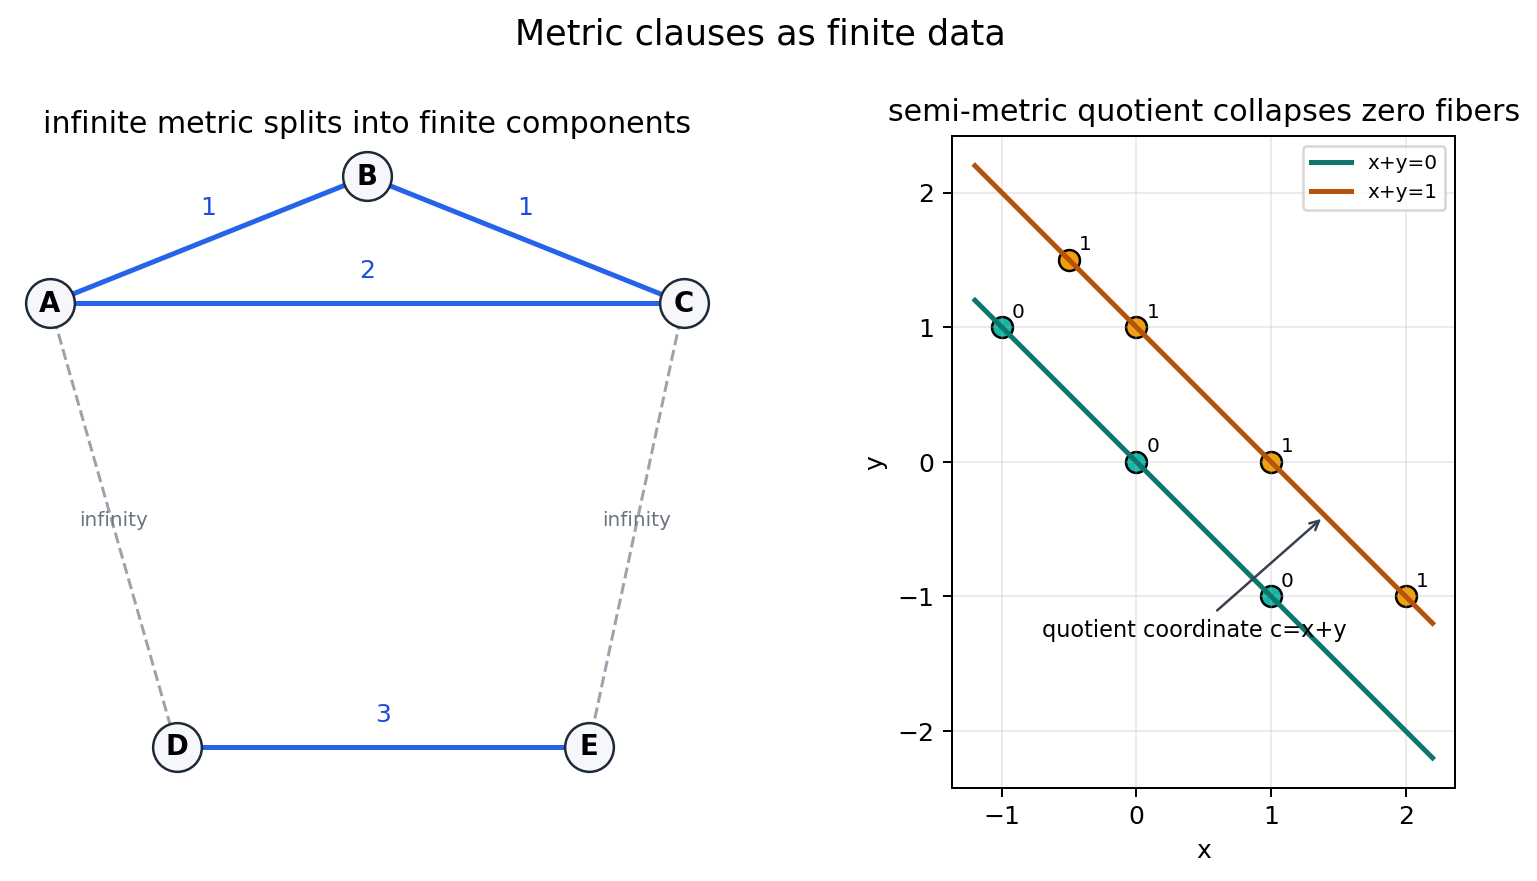

{'infinite_metric_report': {'nonnegative_or_infinite': True,
  'zero_diagonal': True,
  'symmetric': True,
  'positive_off_diagonal': True,
  'triangle_violation_count': 0,
  'sample_violations': []},
 'finite_distance_equivalence_classes': [['A', 'B', 'C'], ['D', 'E']],
 'finite_relation_reflexive_symmetric_transitive': True,
 'semi_metric_report_allows_zero_off_diagonal': {'nonnegative_or_infinite': True,
  'zero_diagonal': True,
  'symmetric': True,
  'positive_off_diagonal': False,
  'triangle_violation_count': 0,
  'sample_violations': [],
  'has_zero_off_diagonal': True},
 'quotient_metric_report': {'nonnegative_or_infinite': True,
  'zero_diagonal': True,
  'symmetric': True,
  'positive_off_diagonal': True,
  'triangle_violation_count': 0,
  'sample_violations': []},
 'quotient_isometric_to_real_coordinate': True,
 'distance_preserving_embedding_max_error': 0.0}

In [2]:
labels = ["A", "B", "C", "D", "E"]
INF = np.inf
D_infinite = np.array([[0,1,2,INF,INF],[1,0,1,INF,INF],[2,1,0,INF,INF],[INF,INF,INF,0,3],[INF,INF,INF,3,0]], dtype=float)
finite_relation = np.isfinite(D_infinite)
classes, unused = [], set(range(len(labels)))
while unused:
    seed = unused.pop()
    cls = {j for j in range(len(labels)) if finite_relation[seed, j]}
    classes.append([labels[j] for j in sorted(cls)])
    unused -= cls

semi_points = np.array([[-1,1],[0,0],[1,-1],[-0.5,1.5],[1,0],[0,1],[2,-1]], dtype=float)
semi_values = semi_points.sum(axis=1)
D_semi = pairwise(semi_points, lambda p, q: abs((p[0]+p[1])-(q[0]+q[1])))
quotient_values = sorted(set(np.round(semi_values, 10)))
D_quotient = pairwise(quotient_values, lambda p, q: abs(p-q))

line_points = np.array([-1.5, -0.25, 0.75, 2.0])
embedded_points = np.column_stack([line_points, np.zeros_like(line_points)])
D_line = pairwise(line_points, lambda p, q: abs(p-q))
D_embedded = pairwise(embedded_points, lambda p, q: float(np.linalg.norm(p-q)))

checks_metric = {
    "infinite_metric_report": metric_report(D_infinite, labels),
    "finite_distance_equivalence_classes": classes,
    "finite_relation_reflexive_symmetric_transitive": bool(np.all(np.diag(finite_relation)) and np.all(finite_relation == finite_relation.T) and all((not (finite_relation[i,j] and finite_relation[j,k])) or finite_relation[i,k] for i in range(len(labels)) for j in range(len(labels)) for k in range(len(labels)))),
    "semi_metric_report_allows_zero_off_diagonal": {**metric_report(D_semi, [f"p{i}" for i in range(len(semi_points))]), "has_zero_off_diagonal": bool(any(abs(D_semi[i,j]) < 1e-9 for i in range(len(semi_points)) for j in range(len(semi_points)) if i != j))},
    "quotient_metric_report": metric_report(D_quotient, [str(v) for v in quotient_values]),
    "quotient_isometric_to_real_coordinate": bool(np.allclose(D_quotient, pairwise(quotient_values, lambda p, q: abs(p-q)))),
    "distance_preserving_embedding_max_error": float(np.max(np.abs(D_line - D_embedded))),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
ax = axes[0]
pos = {"A": (0,0.6), "B": (1,1.0), "C": (2,0.6), "D": (0.4,-0.8), "E": (1.7,-0.8)}
for name, (x, y) in pos.items():
    ax.scatter(x, y, s=380, color="#f5f7fb", edgecolor="#1f2937", zorder=3)
    ax.text(x, y, name, ha="center", va="center", fontsize=11, weight="bold")
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        a, b = labels[i], labels[j]
        x1, y1 = pos[a]; x2, y2 = pos[b]
        if np.isfinite(D_infinite[i,j]):
            ax.plot([x1,x2], [y1,y2], color="#2563eb", lw=2)
            ax.text((x1+x2)/2, (y1+y2)/2+0.08, str(int(D_infinite[i,j])), color="#1d4ed8", ha="center")
        elif (a, b) in [("A","D"), ("C","E")]:
            ax.plot([x1,x2], [y1,y2], color="#9ca3af", lw=1.2, ls="--")
            ax.text((x1+x2)/2, (y1+y2)/2, "infinity", color="#6b7280", ha="center", fontsize=8)
ax.set_title("infinite metric splits into finite components"); ax.set_axis_off(); ax.set_aspect("equal")

ax = axes[1]
xx = np.linspace(-1.2, 2.2, 80)
for c, color in zip([0, 1], ["#0f766e", "#b45309"]):
    ax.plot(xx, c-xx, color=color, lw=2, label=f"x+y={c}")
ax.scatter(semi_points[np.isclose(semi_values,0),0], semi_points[np.isclose(semi_values,0),1], s=70, color="#14b8a6", edgecolor="black")
ax.scatter(semi_points[np.isclose(semi_values,1),0], semi_points[np.isclose(semi_values,1),1], s=70, color="#f59e0b", edgecolor="black")
for p, val in zip(semi_points, semi_values):
    ax.annotate(f"{val:g}", (p[0], p[1]), xytext=(4,4), textcoords="offset points", fontsize=8)
ax.annotate("quotient coordinate c=x+y", xy=(1.4,-0.4), xytext=(-0.7,-1.3), arrowprops=dict(arrowstyle="->", color="#374151"), fontsize=9)
ax.set_title("semi-metric quotient collapses zero fibers"); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal"); ax.grid(True, alpha=0.25); ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Metric clauses as finite data", y=1.02, fontsize=14)
metric_axiom_fig = save_fig(fig, FIG_DIR / "metric-axioms-infinite-quotient.png"); plt.close(fig)
metric_axiom_checks = save_json(checks_metric, CHECK_DIR / "metric-axiom-checks.json")
display_artifact(metric_axiom_fig); display_artifact(metric_axiom_checks)
checks_metric


## 2. Example Metrics and Normed Spaces

The chapter's examples are a warning against treating one set as if it had only one geometry. The real line can use the usual metric or the log metric. A product combines component distances. A dilation keeps the points but rescales every distance. A subspace can inherit ambient distance, while the same circle can carry an intrinsic shorter-arc metric. Normed vector spaces turn vector length into distance by `d(v,w)=|v-w|`.


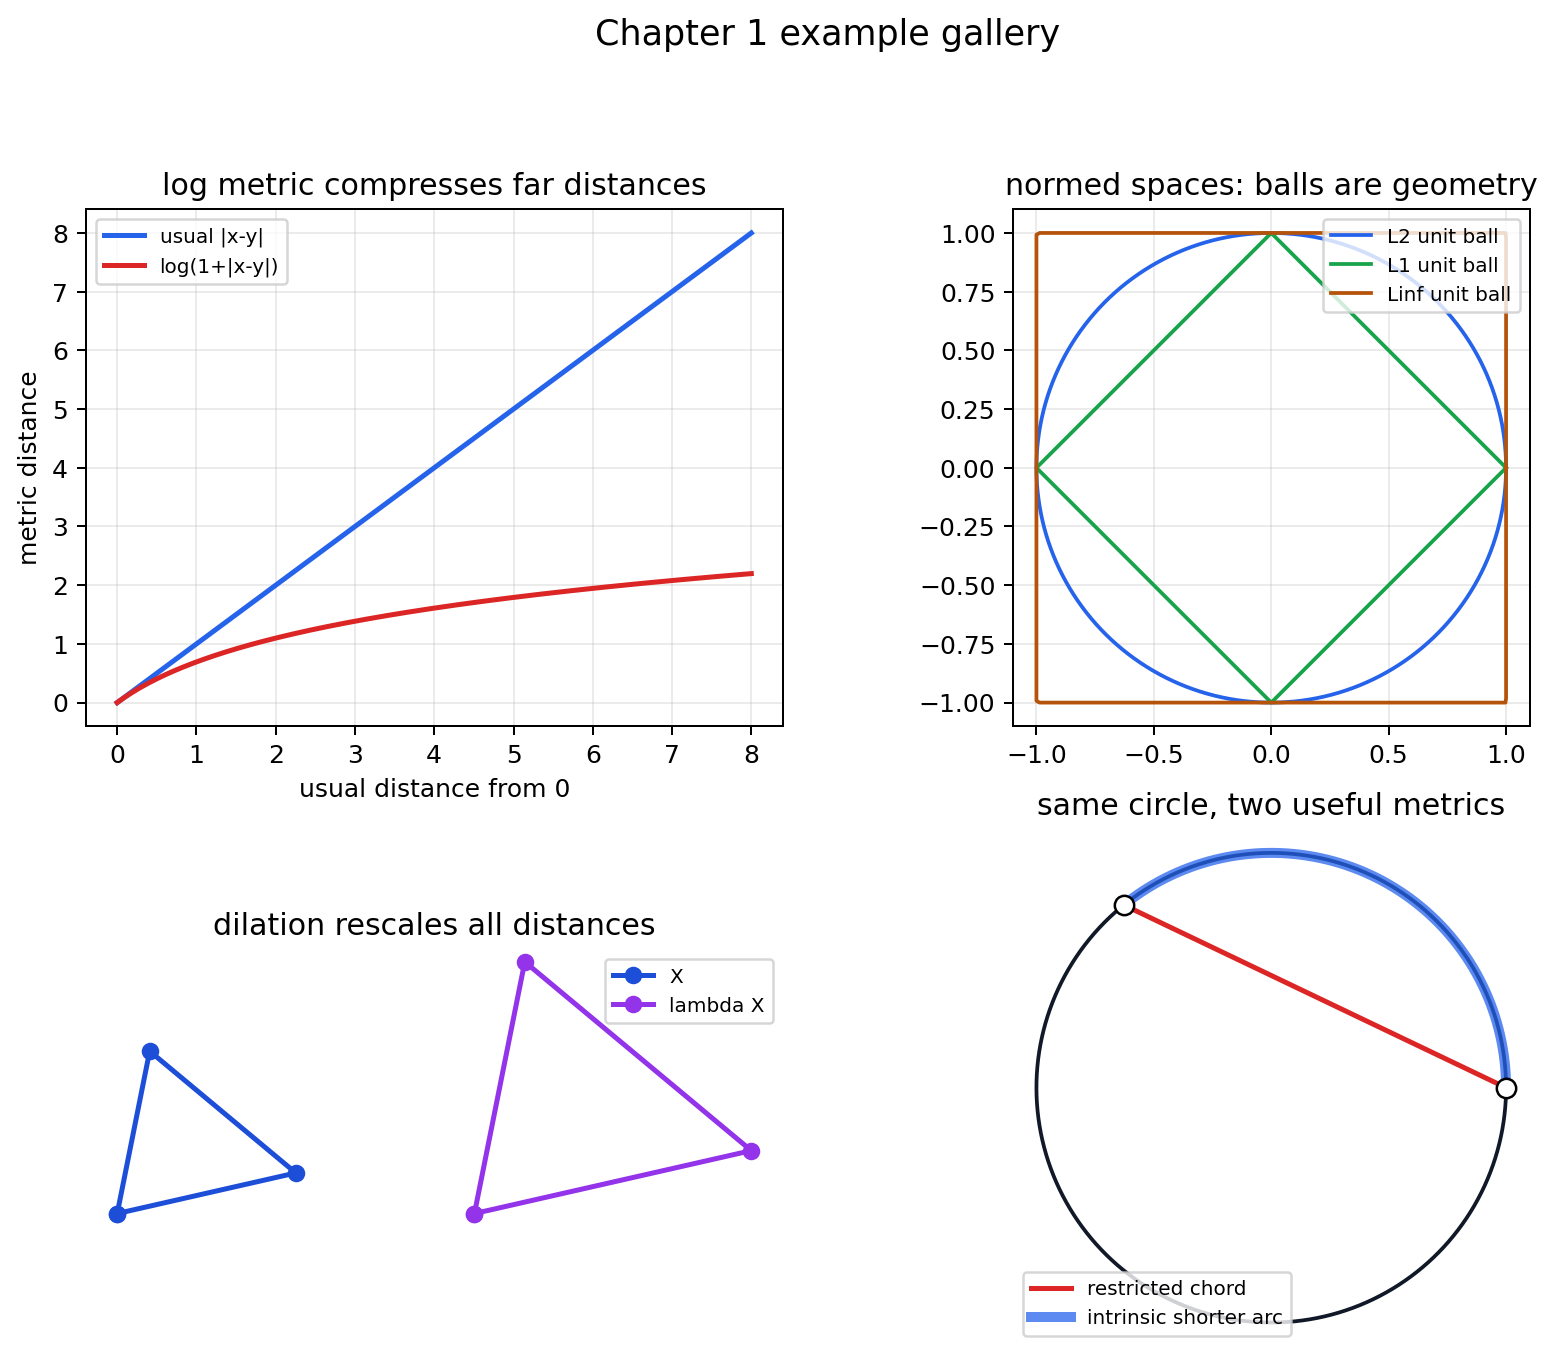

{'discrete_metric': {'nonnegative_or_infinite': True,
  'zero_diagonal': True,
  'symmetric': True,
  'positive_off_diagonal': True,
  'triangle_violation_count': 0,
  'sample_violations': []},
 'log_metric_on_sample': {'nonnegative_or_infinite': True,
  'zero_diagonal': True,
  'symmetric': True,
  'positive_off_diagonal': True,
  'triangle_violation_count': 0,
  'sample_violations': []},
 'euclidean_metric_on_sample': {'nonnegative_or_infinite': True,
  'zero_diagonal': True,
  'symmetric': True,
  'positive_off_diagonal': True,
  'triangle_violation_count': 0,
  'sample_violations': []},
 'product_metric_on_sample': {'nonnegative_or_infinite': True,
  'zero_diagonal': True,
  'symmetric': True,
  'positive_off_diagonal': True,
  'triangle_violation_count': 0,
  'sample_violations': []},
 'dilation_factor': 2.5,
 'dilation_scales_distances_max_error': 0.0,
 'circle_arc_metric_on_sample': {'nonnegative_or_infinite': True,
  'zero_diagonal': False,
  'symmetric': True,
  'positive_off_

In [3]:
rng = np.random.default_rng(427701)
line_sample = np.array([-3.0,-1.0,-0.25,0.0,0.7,2.2,5.0])
plane_sample = rng.normal(size=(8,2))
product_sample = [(float(x), float(y)) for x, y in rng.normal(size=(8,2))]
angles = np.linspace(0, 2*np.pi, 10, endpoint=False)
circle_sample = np.column_stack([np.cos(angles), np.sin(angles)])

def d_discrete(x, y): return 0.0 if x == y else 1.0
def d_log(x, y): return math.log(abs(x-y)+1.0)
def d_euclidean(p, q): return float(np.linalg.norm(np.array(p)-np.array(q)))
def d_product(p, q): return math.hypot(abs(p[0]-q[0]), abs(p[1]-q[1]))
def d_arc(p, q): return math.acos(float(np.clip(np.dot(p, q), -1.0, 1.0)))
def d_chord(p, q): return float(np.linalg.norm(np.array(p)-np.array(q)))

D_discrete = pairwise(list(range(6)), d_discrete)
D_log = pairwise(line_sample, d_log)
D_euclid = pairwise(plane_sample, d_euclidean)
D_product = pairwise(product_sample, d_product)
D_dilated = 2.5 * D_euclid
D_arc = pairwise(circle_sample, d_arc)
D_chord = pairwise(circle_sample, d_chord)

vectors = rng.normal(size=(300,2))
l1_vals = np.sum(np.abs(vectors), axis=1); l2_vals = np.linalg.norm(vectors, axis=1); linf_vals = np.max(np.abs(vectors), axis=1)
nonzero = l2_vals > 1e-12
norm_equivalence_ok = bool(np.all(linf_vals[nonzero] <= l2_vals[nonzero] + 1e-10) and np.all(l2_vals[nonzero] <= l1_vals[nonzero] + 1e-10) and np.all(l1_vals[nonzero] <= math.sqrt(2)*l2_vals[nonzero] + 1e-10) and np.all(l2_vals[nonzero] <= math.sqrt(2)*linf_vals[nonzero] + 1e-10))

example_checks = {
    "discrete_metric": metric_report(D_discrete),
    "log_metric_on_sample": metric_report(D_log),
    "euclidean_metric_on_sample": metric_report(D_euclid),
    "product_metric_on_sample": metric_report(D_product),
    "dilation_factor": 2.5,
    "dilation_scales_distances_max_error": float(np.max(np.abs(D_dilated - 2.5*D_euclid))),
    "circle_arc_metric_on_sample": metric_report(D_arc),
    "circle_chord_restricted_metric_on_sample": metric_report(D_chord),
    "opposite_circle_arc_distance": float(d_arc(np.array([1,0]), np.array([-1,0]))),
    "opposite_circle_chord_distance": float(d_chord(np.array([1,0]), np.array([-1,0]))),
    "norm_equivalence_R2_sample_ok": norm_equivalence_ok,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8.2))
xs = np.linspace(0, 8, 300)
axes[0,0].plot(xs, xs, label="usual |x-y|", color="#2563eb", lw=2)
axes[0,0].plot(xs, np.log1p(xs), label="log(1+|x-y|)", color="#dc2626", lw=2)
axes[0,0].set_title("log metric compresses far distances"); axes[0,0].set_xlabel("usual distance from 0"); axes[0,0].set_ylabel("metric distance"); axes[0,0].grid(True, alpha=0.25); axes[0,0].legend(fontsize=8)
theta = np.linspace(0, 2*np.pi, 600)
axes[0,1].plot(np.cos(theta), np.sin(theta), color="#2563eb", label="L2 unit ball")
axes[0,1].plot(np.sign(np.cos(theta))*np.abs(np.cos(theta))**2, np.sign(np.sin(theta))*np.abs(np.sin(theta))**2, color="#16a34a", label="L1 unit ball")
axes[0,1].plot(np.cos(theta)/np.maximum(np.abs(np.cos(theta)),np.abs(np.sin(theta))), np.sin(theta)/np.maximum(np.abs(np.cos(theta)),np.abs(np.sin(theta))), color="#b45309", label="Linf unit ball")
axes[0,1].set_title("normed spaces: balls are geometry"); axes[0,1].set_aspect("equal"); axes[0,1].grid(True, alpha=0.25); axes[0,1].legend(fontsize=8, loc="upper right")
tri = np.array([[0,0],[1.1,0.25],[0.2,1.0],[0,0]])
axes[1,0].plot(tri[:,0], tri[:,1], "o-", lw=2, color="#1d4ed8", label="X")
axes[1,0].plot(1.55*tri[:,0]+2.2, 1.55*tri[:,1], "o-", lw=2, color="#9333ea", label="lambda X")
axes[1,0].set_title("dilation rescales all distances"); axes[1,0].set_aspect("equal"); axes[1,0].axis("off"); axes[1,0].legend(fontsize=8)
p = np.array([1.0,0.0]); q = np.array([np.cos(2.25), np.sin(2.25)]); arc_t = np.linspace(0, 2.25, 160)
axes[1,1].plot(np.cos(theta), np.sin(theta), color="#111827", lw=1.5)
axes[1,1].plot([p[0],q[0]], [p[1],q[1]], color="#dc2626", lw=2, label="restricted chord")
axes[1,1].plot(np.cos(arc_t), np.sin(arc_t), color="#2563eb", lw=4, alpha=0.75, label="intrinsic shorter arc")
axes[1,1].scatter([p[0],q[0]], [p[1],q[1]], s=60, color="white", edgecolor="black", zorder=4)
axes[1,1].set_title("same circle, two useful metrics"); axes[1,1].set_aspect("equal"); axes[1,1].axis("off"); axes[1,1].legend(fontsize=8, loc="lower left")
fig.suptitle("Chapter 1 example gallery", y=1.01, fontsize=14)
example_fig = save_fig(fig, FIG_DIR / "metric-example-gallery.png"); plt.close(fig)
example_checks_path = save_json(example_checks, CHECK_DIR / "example-metric-checks.json")
display_artifact(example_fig); display_artifact(example_checks_path)
example_checks


## Interactive Lab: Norm Balls and Bi-Lipschitz Equivalence

For finite-dimensional normed spaces, all norms determine the same topology and are Lipschitz equivalent. The Plotly lab varies `p` in `(|x|^p+|y|^p)^(1/p)`. The unit ball changes shape, but it remains trapped between comparable Euclidean balls.


In [4]:
html_lab_path = HTML_DIR / "metric-comparison-lab.html"
if go is None:
    html_lab_path.write_text(f"<html><body><h1>Metric comparison lab unavailable</h1><p>{PLOTLY_IMPORT_ERROR}</p></body></html>", encoding="utf-8")
    lab_checks = {"plotly_available": False, "error": PLOTLY_IMPORT_ERROR}
else:
    theta = np.linspace(0, 2*np.pi, 721)
    p_values = [1.0, 1.25, 1.5, 2.0, 3.0, 6.0, 20.0]
    frames = []
    for p in p_values:
        r = (np.abs(np.cos(theta))**p + np.abs(np.sin(theta))**p) ** (-1.0/p)
        frames.append(go.Frame(data=[go.Scatter(x=r*np.cos(theta), y=r*np.sin(theta), mode="lines", line=dict(width=4, color="#2563eb"))], name=str(p), layout=go.Layout(title_text=f"Lp unit ball in R2, p={p:g}")))
    r0 = (np.abs(np.cos(theta)) + np.abs(np.sin(theta))) ** -1
    fig_lab = go.Figure(data=[
        go.Scatter(x=r0*np.cos(theta), y=r0*np.sin(theta), mode="lines", line=dict(width=4, color="#2563eb"), name="Lp ball"),
        go.Scatter(x=np.cos(theta), y=np.sin(theta), mode="lines", line=dict(width=1.5, color="#111827", dash="dot"), name="L2 reference"),
    ], frames=frames)
    fig_lab.update_layout(title="Lp unit ball in R2, p=1", width=760, height=620, xaxis=dict(scaleanchor="y", scaleratio=1, range=[-1.45,1.45], zeroline=False), yaxis=dict(range=[-1.45,1.45], zeroline=False), margin=dict(l=40,r=20,t=70,b=40), sliders=[{"currentvalue": {"prefix": "p = "}, "steps": [{"label": str(p), "method": "animate", "args": [[str(p)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]} for p in p_values]}])
    fig_lab.write_html(str(html_lab_path), include_plotlyjs=True, full_html=True)
    lab_checks = {"plotly_available": True, "p_values": p_values, "html_bytes": html_lab_path.stat().st_size}
save_json(lab_checks, CHECK_DIR / "interactive-lab-checks.json")
display_artifact(html_lab_path)
lab_checks


{'plotly_available': True,
 'p_values': [1.0, 1.25, 1.5, 2.0, 3.0, 6.0, 20.0],
 'html_bytes': 5045141}

## 3. Topology, Lipschitz Maps, Completeness, and Compactness

Metric topology begins with balls. Lipschitz maps control output distances by input distances, so they are continuous. Completeness asks whether every Cauchy tail lands inside the space. Compactness in metric spaces is equivalent to complete plus totally bounded. The panels below put these ideas next to finite diagnostics.


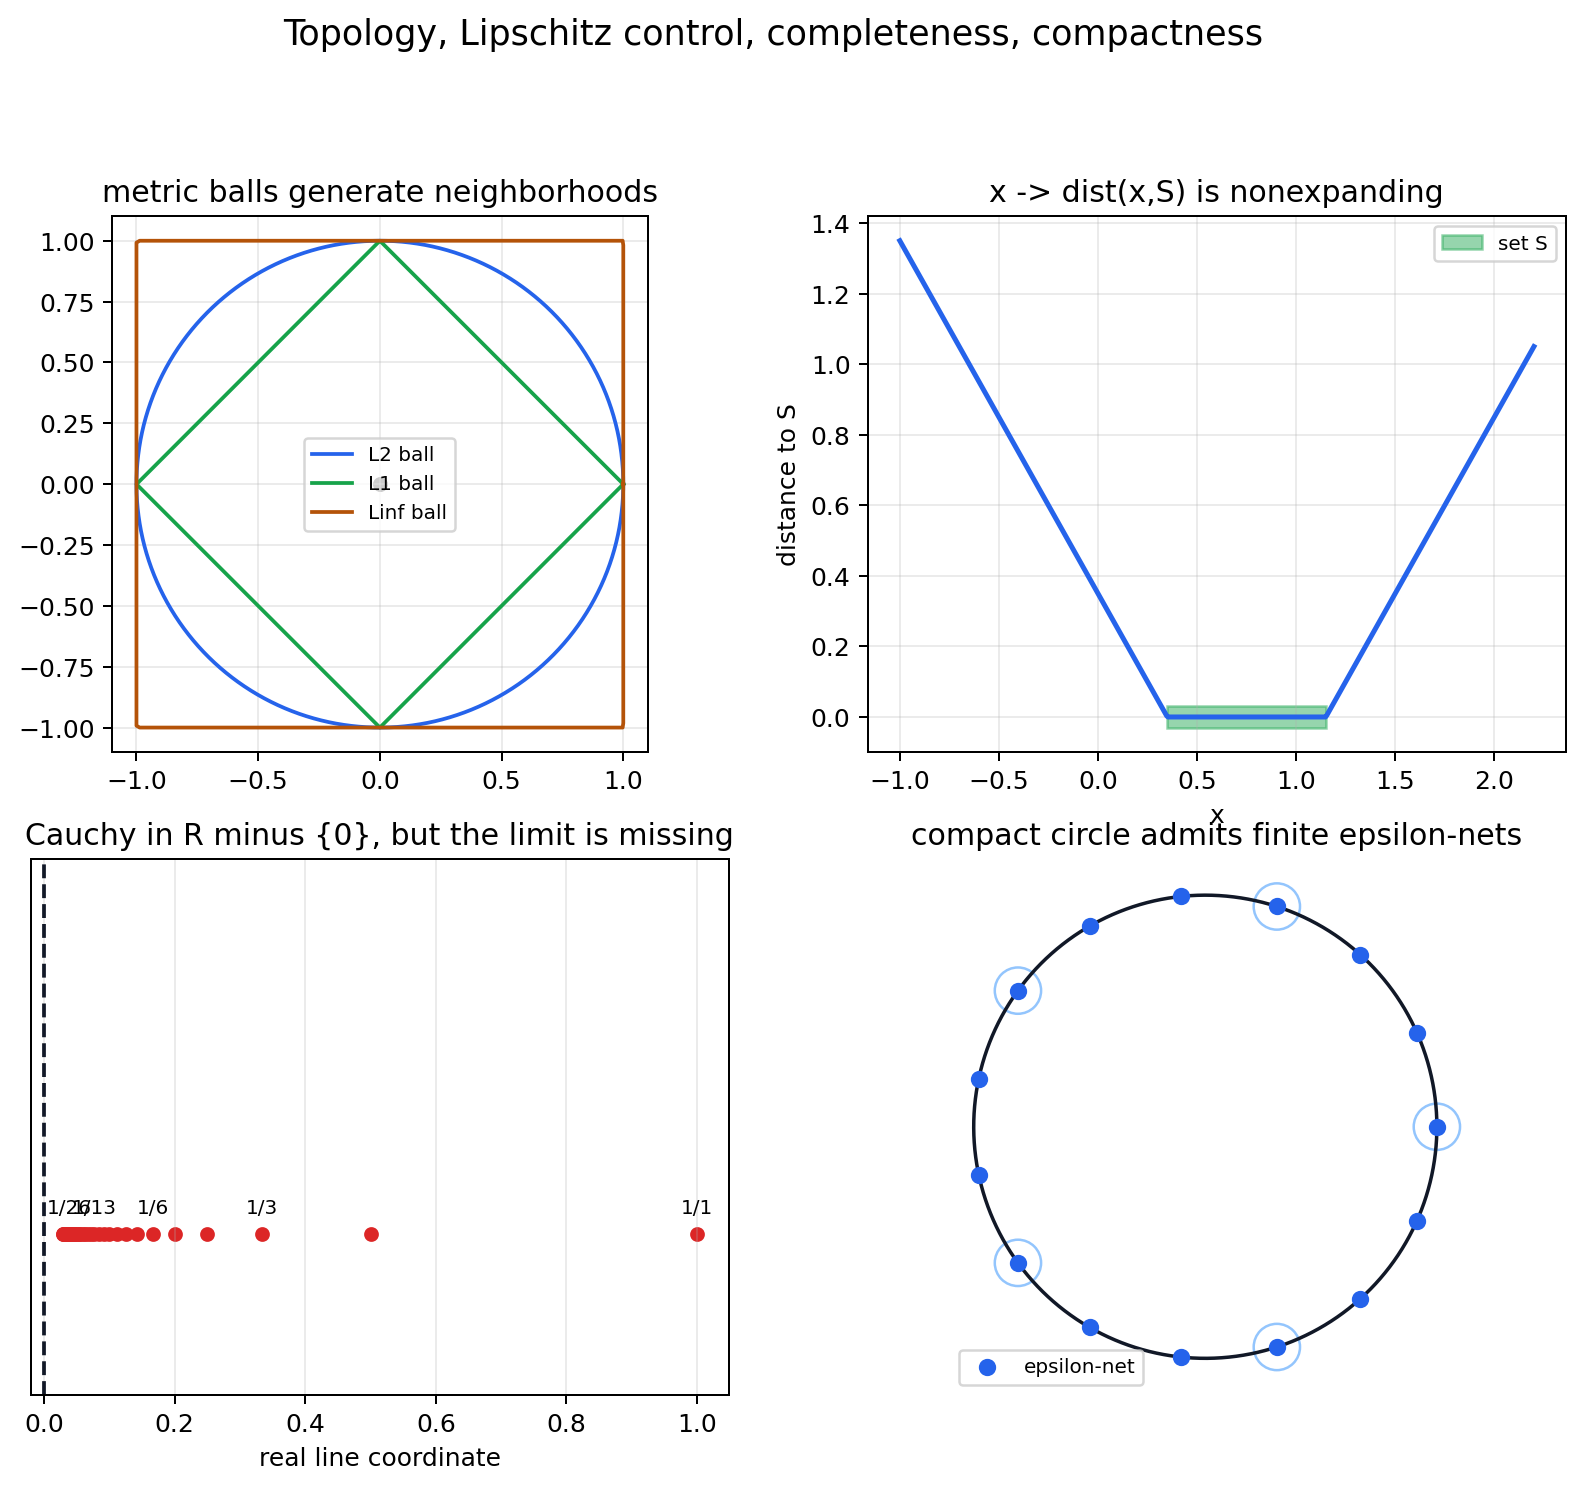

{'distance_to_interval_max_sample_slope': 1.0000000000000346,
 'distance_to_interval_nonexpanding_sample_ok': True,
 'punctured_line_sequence_cauchy_tail_last': 0.003686635944700461,
 'punctured_line_limit_missing': True,
 'contraction_lambda': 0.5,
 'contraction_last_error_to_fixed_point': 6.866455078136102e-06,
 'circle_net_epsilon': 0.42,
 'circle_net_point_count': 15,
 'circle_net_cover_radius_arc_metric': 0.20943951023931984,
 'circle_net_is_epsilon_net': True,
 'simple_cover_lebesgue_lower_bound': 0.037500000000000006}

In [5]:
theta = np.linspace(0, 2*np.pi, 600)
l2_ball = np.column_stack([np.cos(theta), np.sin(theta)])
l1_ball = np.column_stack([np.sign(np.cos(theta))*np.abs(np.cos(theta))**2, np.sign(np.sin(theta))*np.abs(np.sin(theta))**2])
linf_ball = np.column_stack([np.cos(theta)/np.maximum(np.abs(np.cos(theta)),np.abs(np.sin(theta))), np.sin(theta)/np.maximum(np.abs(np.cos(theta)),np.abs(np.sin(theta)))])
xgrid = np.linspace(-1.0, 2.2, 500); set_a, set_b = 0.35, 1.15
dist_to_interval = np.maximum.reduce([set_a-xgrid, np.zeros_like(xgrid), xgrid-set_b])
slopes = np.diff(dist_to_interval) / np.diff(xgrid)
n = np.arange(1, 36); seq = 1.0/n; tail_diameters = np.array([seq[k]-seq[-1] for k in range(len(seq))])
eps = 0.42; net_angles = np.linspace(0, 2*np.pi, math.ceil(2*np.pi/eps), endpoint=False)
net_points = np.column_stack([np.cos(net_angles), np.sin(net_angles)])
cover_radius = float(np.max(np.diff(np.r_[net_angles, 2*np.pi])) / 2)
def contraction(x): return 0.5*x + 0.25
iters = [0.05]
for _ in range(16): iters.append(contraction(iters[-1]))
iters = np.array(iters); fixed_point = 0.5
cover = [(-0.15,0.45),(0.30,0.80),(0.65,1.15)]; probe = np.linspace(0,1,2001)
local_radius = [max([min(x-a, b-x) for a,b in cover if a < x < b] or [0.0]) for x in probe]

topology_checks = {
    "distance_to_interval_max_sample_slope": float(np.max(np.abs(slopes))),
    "distance_to_interval_nonexpanding_sample_ok": bool(np.max(np.abs(slopes)) <= 1.01),
    "punctured_line_sequence_cauchy_tail_last": float(tail_diameters[-5]),
    "punctured_line_limit_missing": True,
    "contraction_lambda": 0.5,
    "contraction_last_error_to_fixed_point": float(abs(iters[-1]-fixed_point)),
    "circle_net_epsilon": eps,
    "circle_net_point_count": int(len(net_points)),
    "circle_net_cover_radius_arc_metric": cover_radius,
    "circle_net_is_epsilon_net": bool(cover_radius <= eps),
    "simple_cover_lebesgue_lower_bound": float(min(local_radius)/2),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
axes[0,0].plot(l2_ball[:,0], l2_ball[:,1], color="#2563eb", label="L2 ball")
axes[0,0].plot(l1_ball[:,0], l1_ball[:,1], color="#16a34a", label="L1 ball")
axes[0,0].plot(linf_ball[:,0], linf_ball[:,1], color="#b45309", label="Linf ball")
axes[0,0].scatter([0], [0], color="black", s=25); axes[0,0].set_title("metric balls generate neighborhoods"); axes[0,0].set_aspect("equal"); axes[0,0].grid(True, alpha=0.25); axes[0,0].legend(fontsize=8)
axes[0,1].plot(xgrid, dist_to_interval, color="#2563eb", lw=2)
axes[0,1].add_patch(Rectangle((set_a,-0.03), set_b-set_a, 0.06, color="#16a34a", alpha=0.45, label="set S"))
axes[0,1].set_title("x -> dist(x,S) is nonexpanding"); axes[0,1].set_xlabel("x"); axes[0,1].set_ylabel("distance to S"); axes[0,1].grid(True, alpha=0.25); axes[0,1].legend(fontsize=8)
axes[1,0].scatter(seq, np.zeros_like(seq), s=24, color="#dc2626"); axes[1,0].axvline(0, color="#111827", ls="--", lw=1.5)
for k in [0,2,5,12,25]: axes[1,0].annotate(f"1/{k+1}", (seq[k],0), xytext=(0,8), textcoords="offset points", ha="center", fontsize=8)
axes[1,0].set_ylim(-0.15,0.35); axes[1,0].set_title("Cauchy in R minus {0}, but the limit is missing"); axes[1,0].set_yticks([]); axes[1,0].set_xlabel("real line coordinate"); axes[1,0].grid(True, axis="x", alpha=0.25)
axes[1,1].plot(np.cos(theta), np.sin(theta), color="#111827", lw=1.4); axes[1,1].scatter(net_points[:,0], net_points[:,1], s=35, color="#2563eb", zorder=3, label="epsilon-net")
for p in net_points[::3]: axes[1,1].add_patch(Circle((p[0],p[1]), 0.10, fill=False, color="#93c5fd", lw=1))
axes[1,1].set_title("compact circle admits finite epsilon-nets"); axes[1,1].set_aspect("equal"); axes[1,1].axis("off"); axes[1,1].legend(fontsize=8, loc="lower left")
fig.suptitle("Topology, Lipschitz control, completeness, compactness", y=1.01, fontsize=14)
topology_fig = save_fig(fig, FIG_DIR / "topology-lipschitz-complete-compact.png"); plt.close(fig)
topology_checks_path = save_json(topology_checks, CHECK_DIR / "topology-lipschitz-completeness-compactness-checks.json")
display_artifact(topology_fig); display_artifact(topology_checks_path)
topology_checks


## Proof Scaffold: Compact Self-Maps Cannot Lose Distance Data

The compact-space isometry theorems use finite nets and separated sets as bookkeeping. If a distance-preserving map from a compact space missed a point, compactness gives a positive gap from the missed point to the image. A maximal separated set would then gain one more separated point, contradicting maximality.


In [6]:
sep_eps = 0.7
candidate_angles = np.linspace(0, 2*np.pi, 200, endpoint=False)
chosen = []
for a in candidate_angles:
    if all(min(abs(a-b), 2*np.pi-abs(a-b)) >= sep_eps - 1e-12 for b in chosen):
        chosen.append(float(a))
net_radius_from_maximal = max(min(min(abs(a-b), 2*np.pi-abs(a-b)) for b in chosen) for a in candidate_angles)
compact_isometry_scaffold = {
    "space_model": "unit circle with arc metric sampled at 200 probes",
    "epsilon": sep_eps,
    "greedy_maximal_epsilon_separated_count": len(chosen),
    "max_distance_from_probe_to_separated_set": float(net_radius_from_maximal),
    "maximal_separated_set_is_epsilon_net_on_probe": bool(net_radius_from_maximal <= sep_eps + 1e-12),
    "proof_role": "finite nets bound separated-set cardinality; adding a missed point at positive distance would exceed the bound",
}
save_json(compact_isometry_scaffold, CHECK_DIR / "compact-isometry-scaffold.json")
compact_isometry_scaffold


{'space_model': 'unit circle with arc metric sampled at 200 probes',
 'epsilon': 0.7,
 'greedy_maximal_epsilon_separated_count': 8,
 'max_distance_from_probe_to_separated_set': 0.5969026041820609,
 'maximal_separated_set_is_epsilon_net_on_probe': True,
 'proof_role': 'finite nets bound separated-set cardinality; adding a missed point at positive distance would exceed the bound'}

## 4. Hausdorff Measure and Hausdorff Dimension

Hausdorff measure charges a small covering set by `diameter^d`. As the exponent changes, the same coverings switch from too expensive to negligible. For the middle-third Cantor construction, stage `k` has `2^k` intervals of diameter `3^-k`, so the model weight is `(2 * 3^-d)^k`. The critical exponent solves `2 * 3^-d = 1`, namely `d = log(2)/log(3)`.


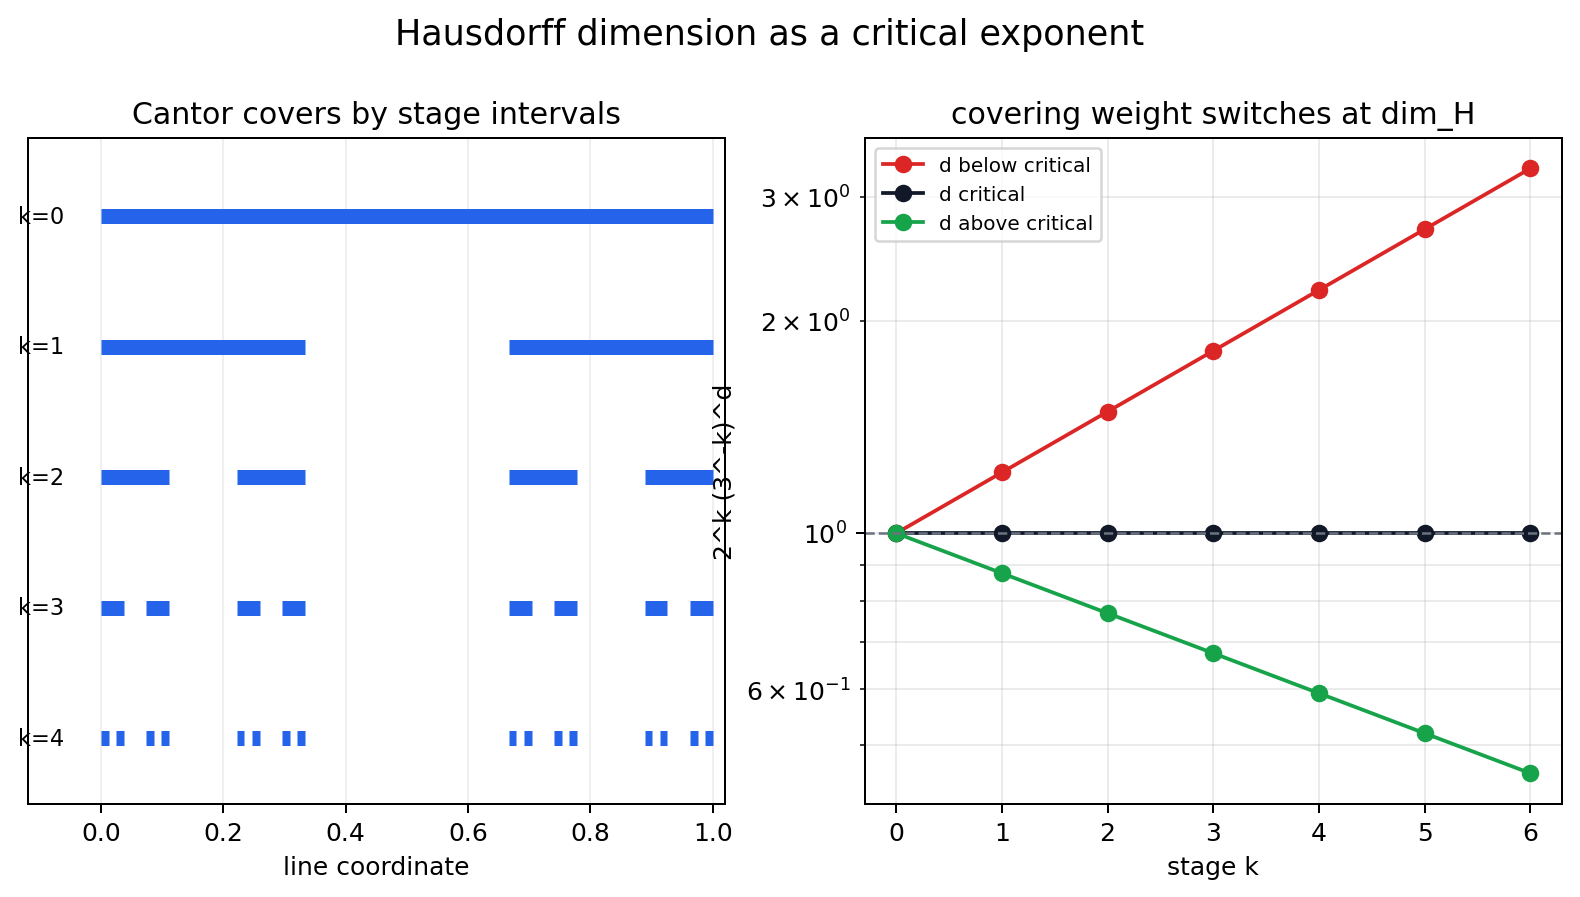

{'cantor_critical_dimension_log2_over_log3': 0.6309297535714574,
 'critical_stage_weights': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0000000000000002, 1.0],
 'below_critical_weight_ratio_last_first': 3.295737292600674,
 'above_critical_weight_ratio_last_first': 0.4561779904708154,
 'critical_weights_constant_sample_ok': True,
 'dimension_monotonicity_examples': {'finite_subset_dimension_at_most_line': True,
  'lipschitz_image_dimension_not_larger': True,
  'Rn_dimension_matches_n_for_n_0_1_2': [0, 1, 2]}}

In [7]:
stages = list(range(7))
def cantor_intervals(stage):
    intervals = [(0.0, 1.0)]
    for _ in range(stage):
        nxt = []
        for a, b in intervals:
            third = (b-a)/3.0
            nxt.append((a, a+third)); nxt.append((b-third, b))
        intervals = nxt
    return intervals

critical_dim = math.log(2) / math.log(3)
d_values = [0.45, critical_dim, 0.75]
weights = {f"d={d:.6f}": [2**k * (3**(-k))**d for k in stages] for d in d_values}
hausdorff_checks = {
    "cantor_critical_dimension_log2_over_log3": critical_dim,
    "critical_stage_weights": weights[f"d={critical_dim:.6f}"],
    "below_critical_weight_ratio_last_first": weights["d=0.450000"][-1] / weights["d=0.450000"][0],
    "above_critical_weight_ratio_last_first": weights["d=0.750000"][-1] / weights["d=0.750000"][0],
    "critical_weights_constant_sample_ok": bool(np.allclose(weights[f"d={critical_dim:.6f}"], np.ones(len(stages)), atol=1e-12)),
    "dimension_monotonicity_examples": {"finite_subset_dimension_at_most_line": True, "lipschitz_image_dimension_not_larger": True, "Rn_dimension_matches_n_for_n_0_1_2": [0,1,2]},
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for stage in range(5):
    y = 4-stage
    for a, b in cantor_intervals(stage):
        axes[0].plot([a,b], [y,y], color="#2563eb", lw=6, solid_capstyle="butt")
    axes[0].text(-0.06, y, f"k={stage}", ha="right", va="center", fontsize=9)
axes[0].set_xlim(-0.12,1.02); axes[0].set_ylim(-0.5,4.6); axes[0].set_title("Cantor covers by stage intervals"); axes[0].set_xlabel("line coordinate"); axes[0].set_yticks([]); axes[0].grid(True, axis="x", alpha=0.2)
for color, d, label in zip(["#dc2626","#111827","#16a34a"], d_values, ["d below critical","d critical","d above critical"]):
    axes[1].plot(stages, [2**k * (3**(-k))**d for k in stages], "o-", color=color, label=label)
axes[1].axhline(1, color="#6b7280", lw=1, ls="--"); axes[1].set_yscale("log"); axes[1].set_title("covering weight switches at dim_H"); axes[1].set_xlabel("stage k"); axes[1].set_ylabel("2^k (3^-k)^d"); axes[1].grid(True, alpha=0.25, which="both"); axes[1].legend(fontsize=8)
fig.suptitle("Hausdorff dimension as a critical exponent", y=1.02, fontsize=14)
hausdorff_fig = save_fig(fig, FIG_DIR / "hausdorff-dimension-cantor.png"); plt.close(fig)
hausdorff_checks_path = save_json(hausdorff_checks, CHECK_DIR / "hausdorff-dimension-checks.json")
display_artifact(hausdorff_fig); display_artifact(hausdorff_checks_path)
hausdorff_checks


## Applied Lab Questions

1. Change the point samples in the metric checks. Which failures are real violations of the metric axioms, and which are only undersampling?
2. Replace the semi-metric by `abs(x-x')`. What are the zero-distance classes, and what quotient appears?
3. In the norm-ball lab, find radii `r < R` so that the Euclidean ball of radius `r` lies inside the displayed norm ball and that norm ball lies inside the Euclidean ball of radius `R`.
4. For the Cantor model, choose an exponent below and above `log(2)/log(3)` and explain why the trends match zero-or-infinite Hausdorff measure away from the critical dimension.


In [8]:
artifact_paths = [
    FIG_DIR / "metric-axioms-infinite-quotient.png",
    FIG_DIR / "metric-example-gallery.png",
    FIG_DIR / "topology-lipschitz-complete-compact.png",
    FIG_DIR / "hausdorff-dimension-cantor.png",
    HTML_DIR / "metric-comparison-lab.html",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "metric-axiom-checks.json",
    CHECK_DIR / "example-metric-checks.json",
    CHECK_DIR / "interactive-lab-checks.json",
    CHECK_DIR / "topology-lipschitz-completeness-compactness-checks.json",
    CHECK_DIR / "compact-isometry-scaffold.json",
    CHECK_DIR / "hausdorff-dimension-checks.json",
]
png_pixel_std = {}
for png_path in [path for path in artifact_paths if path.suffix.lower() == ".png"]:
    pixels = plt.imread(png_path)
    png_pixel_std[rel(png_path)] = float(np.std(pixels))

final_sanity = {
    "source_span_used": source_span,
    "source_sections_covered": [item["section"] for item in source_sections],
    "artifacts": [{"path": rel(path), "exists": path.exists(), "bytes": path.stat().st_size if path.exists() else 0} for path in artifact_paths],
    "visual_pixel_std": png_pixel_std,
    "core_invariants": {
        "png_artifacts_are_nonblank": all(value > 1e-4 for value in png_pixel_std.values()),
        "infinite_metric_axioms_hold": checks_metric["infinite_metric_report"]["triangle_violation_count"] == 0,
        "finite_distance_relation_is_equivalence": checks_metric["finite_relation_reflexive_symmetric_transitive"],
        "semi_metric_has_zero_off_diagonal": checks_metric["semi_metric_report_allows_zero_off_diagonal"]["has_zero_off_diagonal"],
        "semi_metric_quotient_is_metric": checks_metric["quotient_metric_report"]["triangle_violation_count"] == 0,
        "distance_preserving_embedding_exact": checks_metric["distance_preserving_embedding_max_error"] < 1e-12,
        "example_metrics_have_no_sample_triangle_violations": all(example_checks[key]["triangle_violation_count"] == 0 for key in ["discrete_metric","log_metric_on_sample","euclidean_metric_on_sample","product_metric_on_sample","circle_arc_metric_on_sample","circle_chord_restricted_metric_on_sample"]),
        "dilation_scaled_distances": example_checks["dilation_scales_distances_max_error"] < 1e-12,
        "norm_equivalence_R2_sample_ok": example_checks["norm_equivalence_R2_sample_ok"],
        "distance_to_set_nonexpanding_sample_ok": topology_checks["distance_to_interval_nonexpanding_sample_ok"],
        "contraction_iteration_reaches_fixed_point": topology_checks["contraction_last_error_to_fixed_point"] < 1e-4,
        "circle_finite_net_covers": topology_checks["circle_net_is_epsilon_net"],
        "maximal_separated_set_is_net_on_probe": compact_isometry_scaffold["maximal_separated_set_is_epsilon_net_on_probe"],
        "cantor_critical_weights_constant": hausdorff_checks["critical_weights_constant_sample_ok"],
        "cantor_weights_grow_below_shrink_above": hausdorff_checks["below_critical_weight_ratio_last_first"] > 1 and hausdorff_checks["above_critical_weight_ratio_last_first"] < 1,
    },
    "standalone_contract": True,
    "pdf_used_for": "section order, terminology, examples, and theorem orientation only",
}
final_sanity_path = save_json(final_sanity, CHECK_DIR / "final-sanity.json")
assert all(item["exists"] and item["bytes"] > 100 for item in final_sanity["artifacts"]), final_sanity["artifacts"]
assert final_sanity["source_sections_covered"] == ["1.1", "1.2", "1.3", "1.4", "1.5", "1.6", "1.7"]
assert all(final_sanity["core_invariants"].values()), final_sanity["core_invariants"]
final_sanity


{'source_span_used': {'printed_pages': '1-24',
  'pdf_pages': '16-39',
  'sections': ['1.1 Definitions',
   '1.2 Examples',
   '1.3 Metrics and Topology',
   '1.4 Lipschitz Maps',
   '1.5 Complete Spaces',
   '1.6 Compact Spaces',
   '1.7 Hausdorff Measure and Dimension']},
 'source_sections_covered': ['1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7'],
 'artifacts': [{'path': 'artifacts/chapter-01/figures/metric-axioms-infinite-quotient.png',
   'exists': True,
   'bytes': 83212},
  {'path': 'artifacts/chapter-01/figures/metric-example-gallery.png',
   'exists': True,
   'bytes': 176430},
  {'path': 'artifacts/chapter-01/figures/topology-lipschitz-complete-compact.png',
   'exists': True,
   'bytes': 174779},
  {'path': 'artifacts/chapter-01/figures/hausdorff-dimension-cantor.png',
   'exists': True,
   'bytes': 90209},
  {'path': 'artifacts/chapter-01/html/metric-comparison-lab.html',
   'exists': True,
   'bytes': 5045141},
  {'path': 'artifacts/chapter-01/checks/visual-storyboard.jso

## Takeaways

A metric is more than a formula for length: it is a language for topology, maps, completion, compactness, and dimension. Infinite metrics split the world into finite components. Semi-metrics become metrics after a quotient. Lipschitz control turns distance estimates into continuity and measure estimates. Compactness in metric spaces is visible through finite nets and Cauchy limits. Hausdorff dimension is the exponent where small-cover bookkeeping changes behavior.
